# Advanced Stock Analysis & Prediction
This notebook improves upon basic stock analysis by incorporating advanced technical indicators (RSI, MACD, Bollinger Bands), interactive visualizations using Plotly, robust cross-validation, and proper target variable shifting to prevent data leakage.


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import plotly.graph_objects as go
import warnings
warnings.filterwarnings('ignore')


## 1. Fetching Data
We will download historical data for `TCS.NS` from Yahoo Finance.


In [6]:
Ticker = "TCS.NS"

df = yf.download(Ticker, start="2020-01-01", end="2026-07-26", progress=False)
df.head()

Price,Close,High,Low,Open,Volume
Ticker,TCS.NS,TCS.NS,TCS.NS,TCS.NS,TCS.NS
Date,,,,,
2020-01-01,1831.109619,1844.879101,1819.620752,1831.447442,1354908
2020-01-02,1822.703979,1841.542248,1815.565769,1841.542248,2380752
2020-01-03,1859.028687,1877.909233,1828.068187,1828.068187,4655761
2020-01-06,1858.859741,1880.401210,1848.257918,1862.703456,3023209
2020-01-07,1863.422119,1870.855875,1844.795038,1858.902551,2429317


In [7]:
df.columns = df.columns.get_level_values(0)

## 2. Exploratory Data Analysis (EDA)
Using `plotly` to create interactive candlestick charts which are standard for financial time-series data.


In [8]:
fig = go.Figure(data=[go.Candlestick(x=df.index,
                open=df['Open'],
                high=df['High'],
                low=df['Low'],
                close=df['Close'])])

fig.update_layout(title=f'{Ticker} Interactive Candlestick Chart',
                  yaxis_title='Stock Price',
                  xaxis_title='Date')
fig.show()


### 2.1 Distribution of Daily Returns
Understanding the distribution of daily returns helps us identify volatility and outliers.


In [9]:
import plotly.express as px

df['Daily_Return(%)'] = df['Close'].pct_change() * 100
fig_hist = px.histogram(df, x='Daily_Return(%)', nbins=50, 
                        title='Distribution of Daily Returns',
                        marginal='box', # adds a boxplot above
                        color_discrete_sequence=['indianred'])
fig_hist.show()


### 2.2 Seasonality Analysis
Let's see if there are specific months where the stock performs better or worse using a boxplot.


In [10]:
df['Month'] = df.index.month
fig_box = px.box(df, x='Month', y='Daily_Return(%)', 
                 title='Monthly Return Distribution (Seasonality)',
                 color='Month')
fig_box.show()
# Drop 'Month' as we might not use it in our simple model
df.drop('Month', axis=1, inplace=True)


### 2.3 Volume vs Closing Price Trend
Does high volume correlate with significant price movements?


In [20]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

fig_sub = make_subplots(specs=[[{"secondary_y": True}]])

fig_sub.add_trace(
    go.Scatter(
        x=df.index,
        y=df['Close'],
        name="Close Price",
        mode="lines",
        line=dict(color="blue", width=2)   # Change line color here
    ),
    secondary_y=False,
)

fig_sub.add_trace(
    go.Bar(
        x=df.index,
        y=df['Volume'],
        name="Volume",
        opacity=0.9,
        marker_color="green"             # Change bar color here
    ),
    secondary_y=True,
)

fig_sub.update_layout(
    title_text="Close Price & Trading Volume",
    template="plotly_white"
)

fig_sub.update_yaxes(title_text="Price", secondary_y=False)
fig_sub.update_yaxes(title_text="Volume", secondary_y=True)

fig_sub.show()

## 3. Feature Engineering & Technical Indicators
Here we calculate several standard indicators:
- **Daily Returns**
- **Moving Averages (MA)**
- **Bollinger Bands**: Captures volatility.
- **RSI (Relative Strength Index)**: Momentum indicator.
- **MACD (Moving Average Convergence Divergence)**: Trend-following momentum indicator.


In [21]:
# Basic features
df['Daily_Return(%)'] = df['Close'].pct_change() * 100
df['Price_Change'] = df['Close'] - df['Open']
df['High_Low'] = df['High'] - df['Low']
df['Volume_Change'] = df['Volume'].pct_change()

# Moving Averages
df['MA20'] = df['Close'].rolling(20).mean()
df['MA50'] = df['Close'].rolling(50).mean()

# Bollinger Bands
df['BB_std'] = df['Close'].rolling(20).std()
df['BB_Upper'] = df['MA20'] + (df['BB_std'] * 2)
df['BB_Lower'] = df['MA20'] - (df['BB_std'] * 2)

# RSI (14-day)
delta = df['Close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / loss
df['RSI'] = 100 - (100 / (1 + rs))

# MACD
exp1 = df['Close'].ewm(span=12, adjust=False).mean()
exp2 = df['Close'].ewm(span=26, adjust=False).mean()
df['MACD'] = exp1 - exp2
df['Signal_Line'] = df['MACD'].ewm(span=9, adjust=False).mean()

# Drop rows with NaN from rolling calculations
df.dropna(inplace=True)


In [23]:
# Calculate Moving Averages
df['MA20'] = df['Close'].rolling(window=20).mean()
df['MA50'] = df['Close'].rolling(window=50).mean()

fig = make_subplots(specs=[[{"secondary_y": True}]])

# Close Price
fig.add_trace(
    go.Scatter(
        x=df.index,
        y=df['Close'],
        name='Close Price',
        mode='lines',
        line=dict(color='#00FF7F', width=2)
    ),
    secondary_y=False
)

# 20-Day Moving Average
fig.add_trace(
    go.Scatter(
        x=df.index,
        y=df['MA20'],
        name='20-Day MA',
        mode='lines',
        line=dict(color='orange', width=2, dash='dash')
    ),
    secondary_y=False
)

# 50-Day Moving Average
fig.add_trace(
    go.Scatter(
        x=df.index,
        y=df['MA50'],
        name='50-Day MA',
        mode='lines',
        line=dict(color='red', width=2)
    ),
    secondary_y=False
)

# Volume
fig.add_trace(
    go.Bar(
        x=df.index,
        y=df['Volume'],
        name='Volume',
        marker_color='blue'
    ),
    secondary_y=True
)

fig.update_layout(
    title='Stock Price Analysis Dashboard',
    height=700,
    width=1400,
    hovermode='x unified',
    legend=dict(
        orientation='h',
        y=1.02,
        x=0
    )
)

fig.update_xaxes(
    showgrid=False,
    rangeslider_visible=True
)

fig.update_yaxes(
    title_text='Stock Price (₹)',
    showgrid=True,
    secondary_y=False
)

fig.update_yaxes(
    title_text='Volume',
    showgrid=False,
    secondary_y=True
)

fig.show()

## 4. Preventing Data Leakage
Instead of predicting today's Close price using today's High, Low, and Open (which is cheating since we don't know them until the day ends), we shift the target variable by -1.
This means we use today's data to predict **tomorrow's** Close price.


In [24]:
# Create the target variable: Tomorrow's Close Price
df['Target_Next_Close'] = df['Close'].shift(-1)

# Drop the last row because it won't have a target value
df.dropna(inplace=True)

# Define Features (X) and Target (y)
# We can drop the original 'Close' if we want, or keep it as a feature to predict tomorrow's close.
x = df.drop(columns=['Target_Next_Close'])
y = df['Target_Next_Close']

print("Features shape:", x.shape)
print("Target shape:", y.shape)


Features shape: (1529, 17)
Target shape: (1529,)


## 5. Train-Test Split and Scaling
Because this is time-series data, we split chronologically.


In [25]:
# Replace infinity with NaN
x = x.replace([np.inf, -np.inf], np.nan)

# Remove rows containing NaN
x = x.dropna()

# Make y match X
y = y.loc[x.index]

In [26]:
train_size = int(len(df) * 0.8)

x_train, x_test = x[:train_size], x[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)


## 6. XGBoost Model & Hyperparameter Tuning
Using `RandomizedSearchCV` coupled with `TimeSeriesSplit` to find the best hyperparameters without looking into the future.


In [27]:
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

# TimeSeriesSplit ensures we don't leak future data during cross-validation
tscv = TimeSeriesSplit(n_splits=3)

# Define parameter grid
param_grid = {
    'n_estimators': [100, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb_base = XGBRegressor(objective='reg:squarederror', random_state=42)

# Randomized Search for faster tuning
random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_grid,
    n_iter=10,
    scoring='neg_mean_absolute_error',
    cv=tscv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search.fit(x_train, y_train)

print("Best Parameters:", random_search.best_params_)
best_model = random_search.best_estimator_


Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Parameters: {'subsample': 1.0, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 0.8}


## 7. Model Evaluation
Evaluate on the test set using standard metrics, plus MAPE (Mean Absolute Percentage Error) for better business interpretability.


In [28]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = best_model.predict(x_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Calculate MAPE
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print(f"Mean Absolute Error : {mae:.2f}")
print(f"Mean Squared Error  : {mse:.2f}")
print(f"Root Mean Sq Error  : {rmse:.2f}")
print(f"R-squared Score     : {r2:.4f}")
print(f"MAPE                : {mape:.2f}%")


Mean Absolute Error : 53.67
Mean Squared Error  : 5147.87
Root Mean Sq Error  : 71.75
R-squared Score     : 0.9663
MAPE                : 2.10%


## 8. Visualizing Predictions
Plot actual vs predicted prices for the test set.


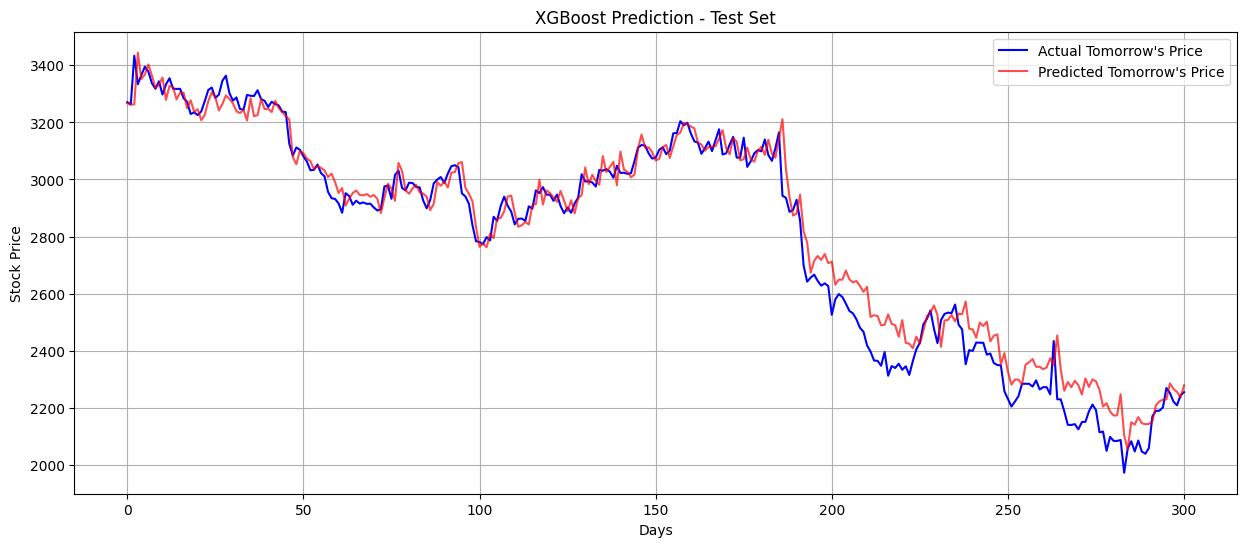

In [29]:
plt.figure(figsize=(15,6))
plt.plot(y_test.values, label="Actual Tomorrow's Price", color="blue")
plt.plot(y_pred, label="Predicted Tomorrow's Price", color="red", alpha=0.7)
plt.title("XGBoost Prediction - Test Set")
plt.xlabel("Days")
plt.ylabel("Stock Price")
plt.legend()
plt.grid(True)
plt.show()


## 9. Feature Importance
Determine which features (including our new technical indicators) contributed the most to the predictions.


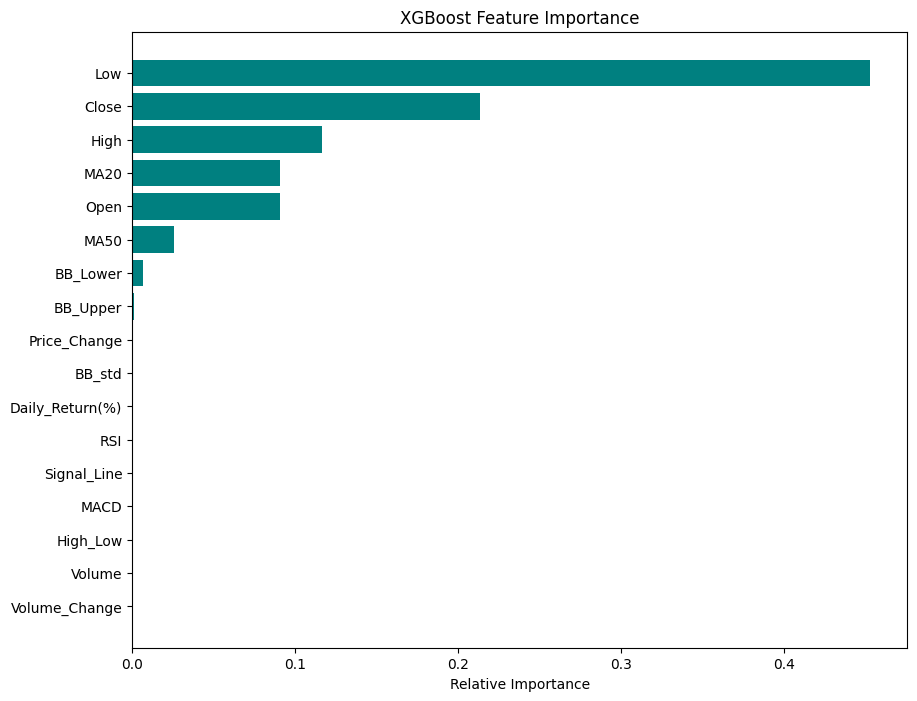

In [30]:
importance = pd.DataFrame({
    'Feature': x.columns,
    'Importance': best_model.feature_importances_
})
importance = importance.sort_values(by='Importance', ascending=True)

plt.figure(figsize=(10,8))
plt.barh(importance['Feature'], importance['Importance'], color='teal')
plt.title("XGBoost Feature Importance")
plt.xlabel("Relative Importance")
plt.show()


## 10. Save Cleaned Dataset and Model


In [32]:
import pickle

# Update the dataset with our new features for the streamlit app
df.to_csv('cleaned_dataset_v2.csv', index=False)

# Save the tuned model
with open('best_model_v2.pkl', 'wb') as f:
    pickle.dump(best_model, f)
    
print("Saved best_model_v2.pkl and cleaned_dataset_v2.csv successfully!")


Saved best_model_v2.pkl and cleaned_dataset_v2.csv successfully!
